 # Data Cleaning , Preprocessing & Outlier Detection

## Import Libraries

In [127]:
import pandas as pd
import numpy as np

## Load Dataset

In [128]:
df = pd.read_csv(r'C:\Users\PRO\Downloads\hotel_bookings.csv')
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


## Dataset Overview

In [129]:
df.shape

(119390, 32)

In [130]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Handling Missing & Invalid Values

In [132]:
# Strip spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Replace NULL-like values
null_values = ['NULL', 'null', 'NaN', 'nan', 'None', '']
df = df.replace(null_values, np.nan)

df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [133]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

,Missing Count,Missing %
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
reserved_room_type,0,0.000000
assigned_room_type,0,0.000000
booking_changes,0,0.000000
deposit_type,0,0.000000
hotel,0,0.000000
previous_cancellations,0,0.000000


### droping 'agent',and'company' beacuse of hav

In [134]:
df.drop(['agent','company'],axis=1,inplace=True)

In [135]:
df['country']=df['country'].fillna('Unknown')

In [136]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          4
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

## Datatype Fixation

In [137]:
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'],
    format='%Y-%m-%d',   # enforce correct format
    errors='coerce'
)

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64

In [141]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Feature Engineering

In [144]:
df['total_stay'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['Revenue']=df['adr'] * df['total_stay']
df['Total_Previous_Bookings']=df['previous_cancellations'] + df['previous_bookings_not_canceled']
df['Cancellation_Rate']=df['previous_cancellations'] / (df['Total_Previous_Bookings'] + 1)
df['Booking_Change_Rate']=df['booking_changes'] / (df['lead_time'] + 1)

In [145]:
df['res_year'] = df['reservation_status_date'].dt.year
df['res_month'] = df['reservation_status_date'].dt.month
df['res_day'] = df['reservation_status_date'].dt.day
df['res_weekday'] = df['reservation_status_date'].dt.weekday

In [146]:
df['pricepernight'] = df['adr'] / (df['total_stay'] + 1)

In [147]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_stay,Revenue,Total_Previous_Bookings,Cancellation_Rate,Booking_Change_Rate,res_year,res_month,res_day,res_weekday,pricepernight
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,7,672.98,0,0.0,0.0,2017,9,6,2,12.01750
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,7,1578.01,0,0.0,0.0,2017,9,7,3,28.17875
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,7,1103.97,0,0.0,0.0,2017,9,7,3,19.71375
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,7,730.80,0,0.0,0.0,2017,9,7,3,13.05000
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,9,1360.80,0,0.0,0.0,2017,9,7,3,15.12000


## Outlier Removal (IQR Method)

In [148]:
df_cleanednegative = df[df['adr'] >= 0]
df_cleanednegative.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119389 entries, 0 to 119389
Data columns (total 40 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119389 non-null  object        
 1   is_canceled                     119389 non-null  int64         
 2   lead_time                       119389 non-null  int64         
 3   arrival_date_year               119389 non-null  int64         
 4   arrival_date_month              119389 non-null  object        
 5   arrival_date_week_number        119389 non-null  int64         
 6   arrival_date_day_of_month       119389 non-null  int64         
 7   stays_in_weekend_nights         119389 non-null  int64         
 8   stays_in_week_nights            119389 non-null  int64         
 9   adults                          119389 non-null  int64         
 10  children                        119385 non-null  float64     

In [149]:
df_cleanednegative['adr'].max()

5400.0

In [150]:
Q1 = df_cleanednegative['adr'].quantile(0.25)
Q3 = df_cleanednegative['adr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower, "Upper:", upper)

Lower: -15.774999999999991 Upper: 211.065


In [151]:
upper = df_cleanednegative['adr'].quantile(0.99)
lower = df_cleanednegative['adr'].quantile(0.01)

df_cleanednegative['adr'] = df_cleanednegative['adr'].clip(lower, upper)

C:\Users\PRO\AppData\Local\Temp\ipykernel_18316\2111461049.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleanednegative['adr'] = df_cleanednegative['adr'].clip(lower, upper)


In [152]:
# Optional: normalize
df_cleanednegative['adr_log'] = np.log1p(df_cleanednegative['adr'])

C:\Users\PRO\AppData\Local\Temp\ipykernel_18316\2951147565.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleanednegative['adr_log'] = np.log1p(df_cleanednegative['adr'])


In [153]:
df_cleanednegative

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,Revenue,Total_Previous_Bookings,Cancellation_Rate,Booking_Change_Rate,res_year,res_month,res_day,res_weekday,pricepernight,adr_log
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.00,0,0.0,0.008746,2015,7,1,2,0.000000,0.000000
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.00,0,0.0,0.005420,2015,7,1,2,0.000000,0.000000
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.00,0,0.0,0.000000,2015,7,2,3,37.500000,4.330733
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.00,0,0.0,0.000000,2015,7,2,3,37.500000,4.330733
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,196.00,0,0.0,0.000000,2015,7,3,4,32.666667,4.595120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,672.98,0,0.0,0.000000,2017,9,6,2,12.017500,4.576153
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,1578.01,0,0.0,0.000000,2017,9,7,3,28.178750,5.422436
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,1103.97,0,0.0,0.000000,2017,9,7,3,19.713750,5.067079
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,730.80,0,0.0,0.000000,2017,9,7,3,13.050000,4.657763


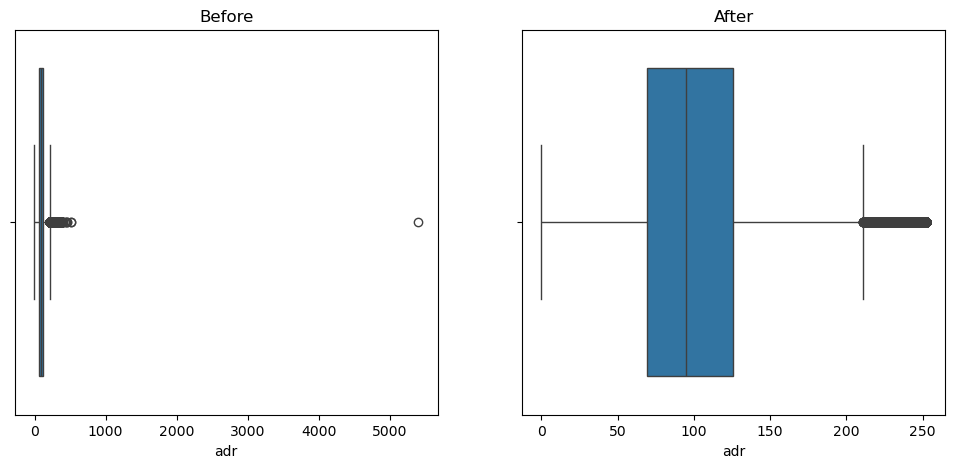

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['adr'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(x=df_cleanednegative['adr'])
plt.title("After")

plt.show()

## Save Clean Dataset

In [121]:
df_cleanednegative.to_csv('cleaned_data.csv', index=False)

In [29]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_stay',
       'Revenue', 'Total_Previous_Bookings', 'Cancellation_Rate',
       'Booking_Change_Rate', 'res_year', 'res_month', 'res_day',
       'res_weekday', 'pricepernight'],
      dtype='object')

In [154]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_stay,Revenue,Total_Previous_Bookings,Cancellation_Rate,Booking_Change_Rate,res_year,res_month,res_day,res_weekday,pricepernight
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0.00,0,0.0,0.008746,2015,7,1,2,0.000000
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0.00,0,0.0,0.005420,2015,7,1,2,0.000000
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,1,75.00,0,0.0,0.000000,2015,7,2,3,37.500000
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,1,75.00,0,0.0,0.000000,2015,7,2,3,37.500000
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2,196.00,0,0.0,0.000000,2015,7,3,4,32.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,7,672.98,0,0.0,0.000000,2017,9,6,2,12.017500
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,7,1578.01,0,0.0,0.000000,2017,9,7,3,28.178750
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,7,1103.97,0,0.0,0.000000,2017,9,7,3,19.713750
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,7,730.80,0,0.0,0.000000,2017,9,7,3,13.050000


In [162]:
df.to_csv('cleaned_data.csv',index=False)